<a href="https://colab.research.google.com/github/Araa02/Araa/blob/main/BISMILLAH_SKRIPSI_ARA_REAL_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diabetes Prediction**




In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# ignore warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# load a dataset
df = pd.read_csv('/pima-indians-diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Data Assesing and Data Cleaning**

Data Assessment is the process of identifying and understanding existing data, including exploring its structure, quality, and usefulness. This involves identifying issues such as missing, duplicate, or invalid data, as well as evaluating the suitability of the data for analysis or other purposes.

Data Cleaning is the process of addressing issues identified during data assessment, such as filling in missing values, removing duplicates, or correcting incorrect formats. The goal is to ensure the data is clean, consistent, and ready for use in further analysis or modeling.



In [3]:
# Displaying the number of rows and columns in a DataFrame
df.shape

(768, 9)

In [4]:
# Displays information about the DataFrame, including the number of non-zero values, data types, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Counting the number of missing values (NaN) in each column of a DataFrame
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetespedigreeFunction,0
Age,0
Outcome,0


In [6]:
# Counting the number of duplicate rows in a DataFrame
df.duplicated().sum()

np.int64(0)

In [7]:
# Displaying summary statistics from a DataFrame
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Based on the data assessment and data cleaning processes that have been performed, the dataset used contains no missing values or duplicate data. Next, using the `info()` function, we can identify the features present in the dataset, which include Pregnancies, Glucose, Blood Pressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, and Outcome. Additionally, using the `describe()` function provides a statistical summary of the dataset, such as the mean, standard deviation, minimum and maximum values, and so on.

# **Exploratory Data Analysis (EDA)**
Exploratory Data Analysis (EDA) is an initial investigation of data to analyze its characteristics, identify patterns and anomalies, and examine assumptions within the data. This technique typically involves statistical methods and graphical representations or visualizations.

The code below shows a comparison of the number of people with diabetes and those without diabetes.

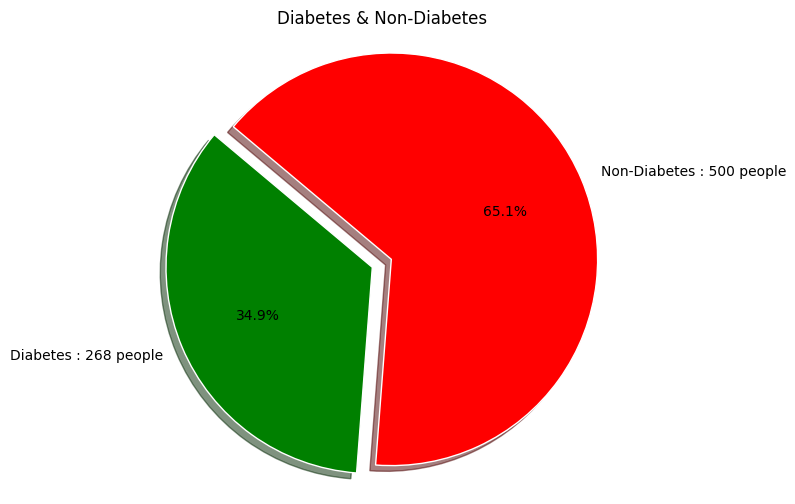

In [8]:
import matplotlib.pyplot as plt

# Group the data by Outcome value
diabetes = df[df['Outcome'] == 1]
non_diabetes = df[df['Outcome'] == 0]

# Count the number of data points for each group
num_diabetes = len(diabetes)
num_non_diabetes = len(non_diabetes)

# Create a pie chart
labels = f'Diabetes : {num_diabetes} people', f'Non-Diabetes : {num_non_diabetes} people'
sizes = [num_diabetes, num_non_diabetes]
colors = ['Green', 'Red']  # Use green and red
explode = (0.1, 0)  # Separate the “Diabetes” section

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140, wedgeprops={'edgecolor': 'white'})
plt.axis('equal')  # Make sure the pie chart is circular
plt.title('Diabetes & Non-Diabetes')
plt.show()

Create a histogram for each numeric column in the DataFrame

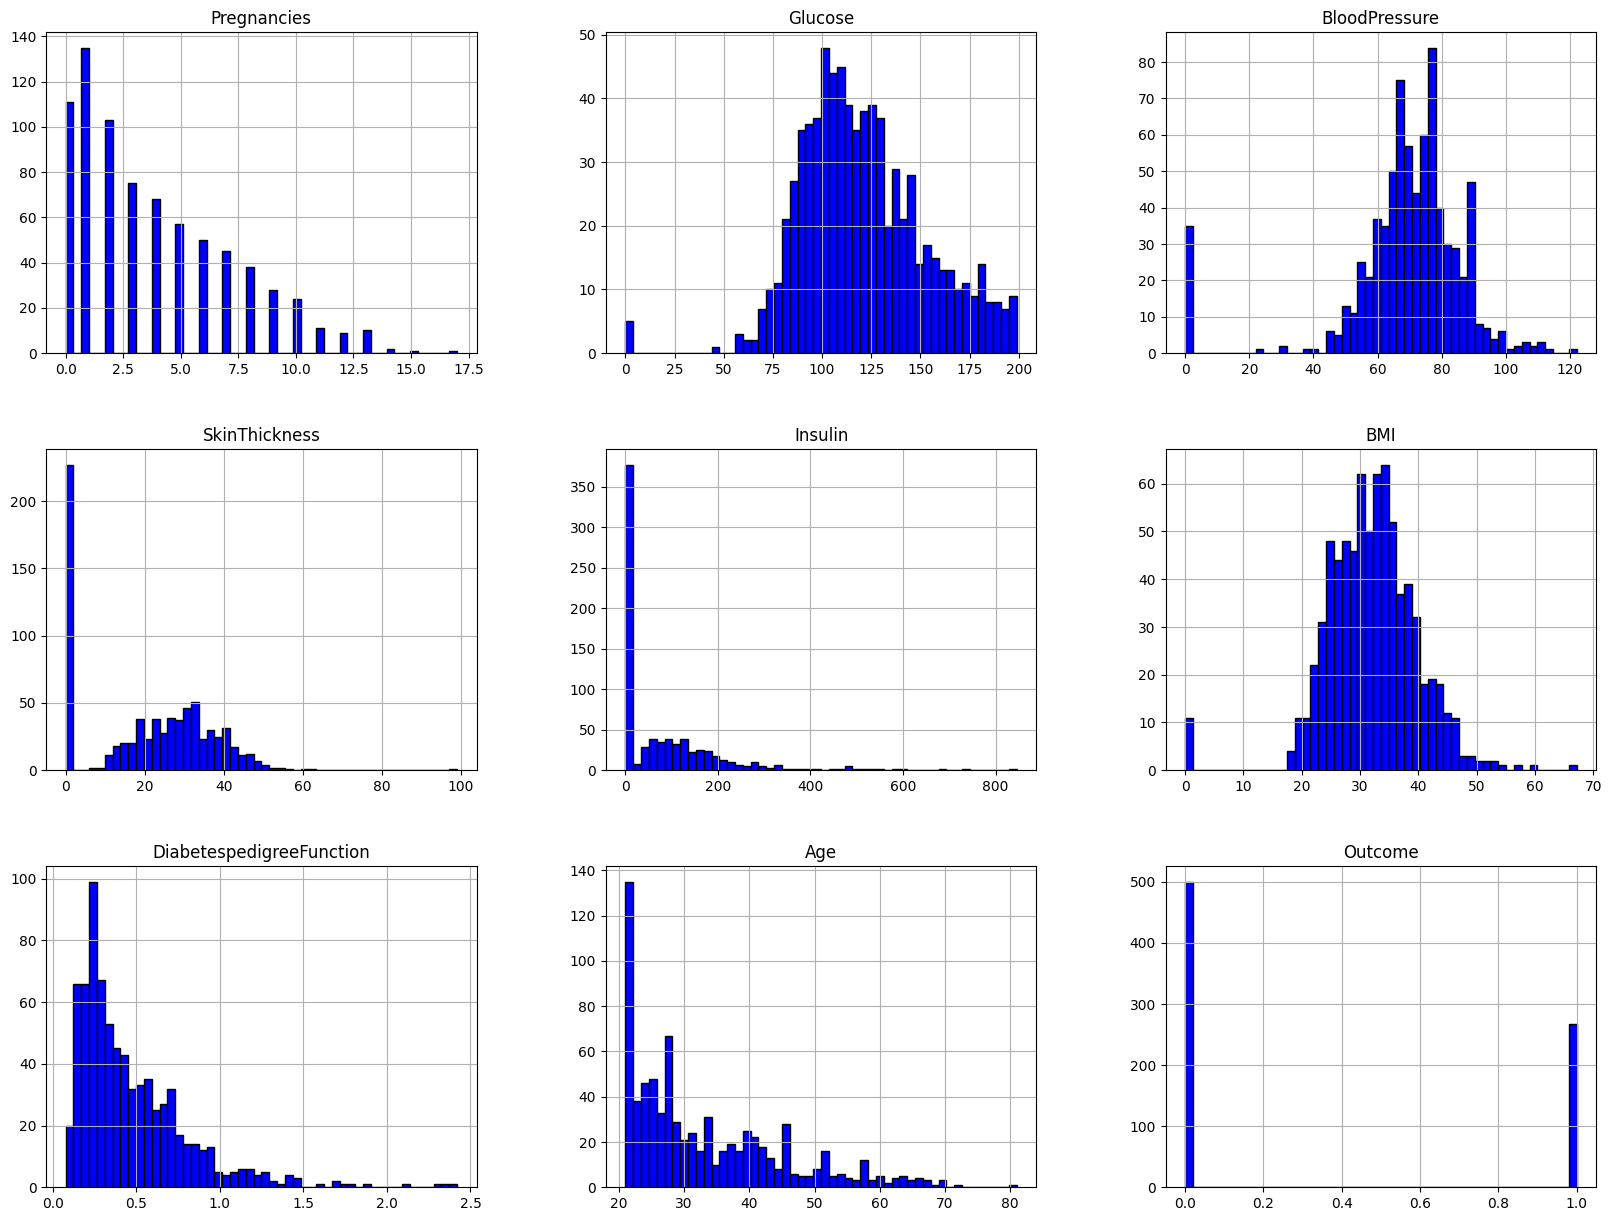

In [9]:
df.hist(bins=50, figsize=(20, 15), color='blue', edgecolor='black')
plt.show()

The code below is designed to calculate the correlation between the numerical columns in the df DataFrame and then sort them based on their correlation with the ‘Result’ column.

If the correlation coefficient approaches +1, this indicates a positive relationship between the two variables. This means that when one variable increases, the other is likely to increase as well. Conversely, if the correlation coefficient approaches -1, this indicates a negative relationship between the two variables. This means that when one variable increases, the other tends to decrease.

If the correlation coefficient approaches 0, this indicates no linear relationship between the two variables. However, it is important to remember that the absence of a linear correlation does not mean there is no relationship at all; it simply means that the relationship cannot be explained in the same way as with positive or negative correlations.

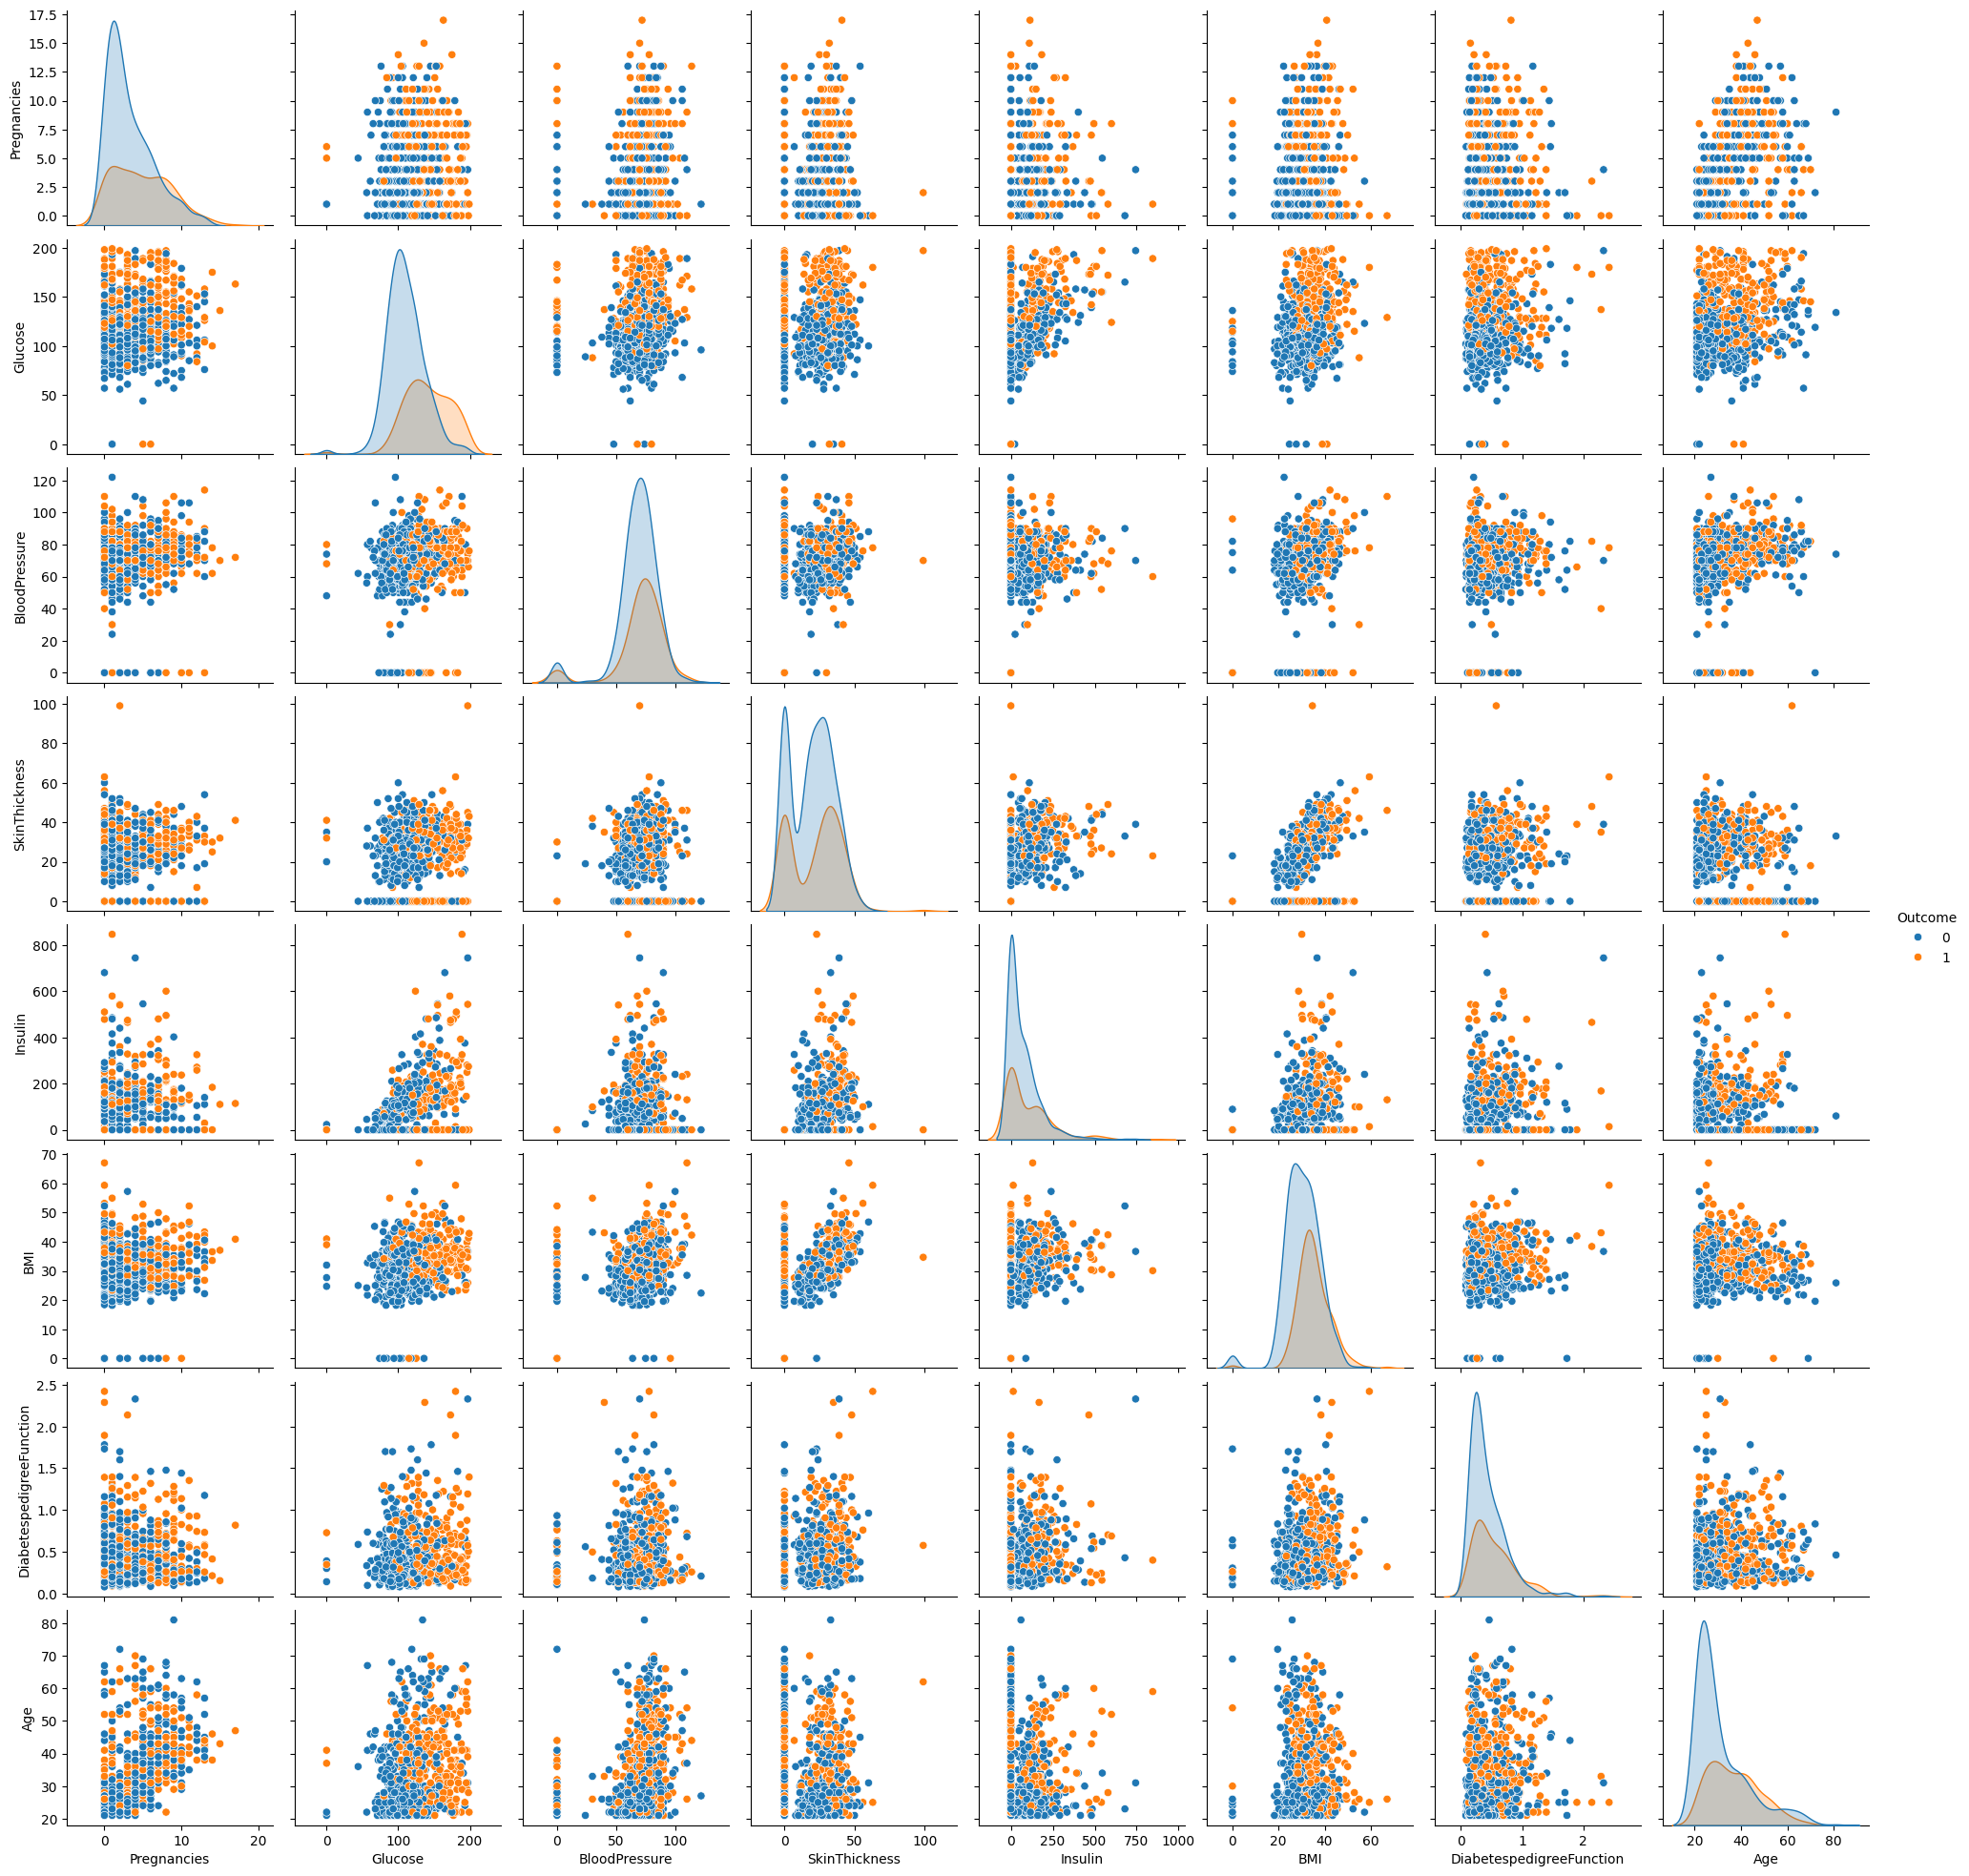

In [10]:
# pairplot
sns.pairplot(df, hue="Outcome")

Text(0.5, 1.0, 'Feature Correlation Heatmap')

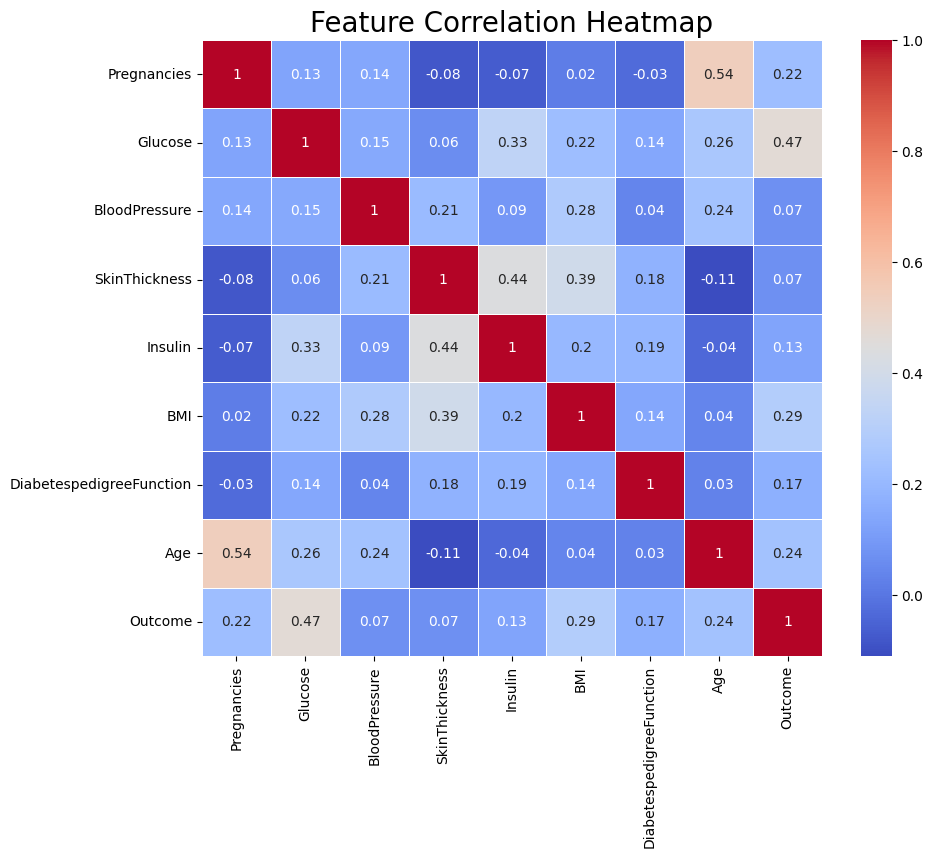

In [11]:
# Displaying a correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr().round(2)

# To print the value inside the box, use the anot=True parameter
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Feature Correlation Heatmap", size=20)

In [12]:
df.shape

(768, 9)

In this project, we will detect outliers using the boxplot data visualization technique. We will then handle those outliers using the IQR (Interquartile Range) method.

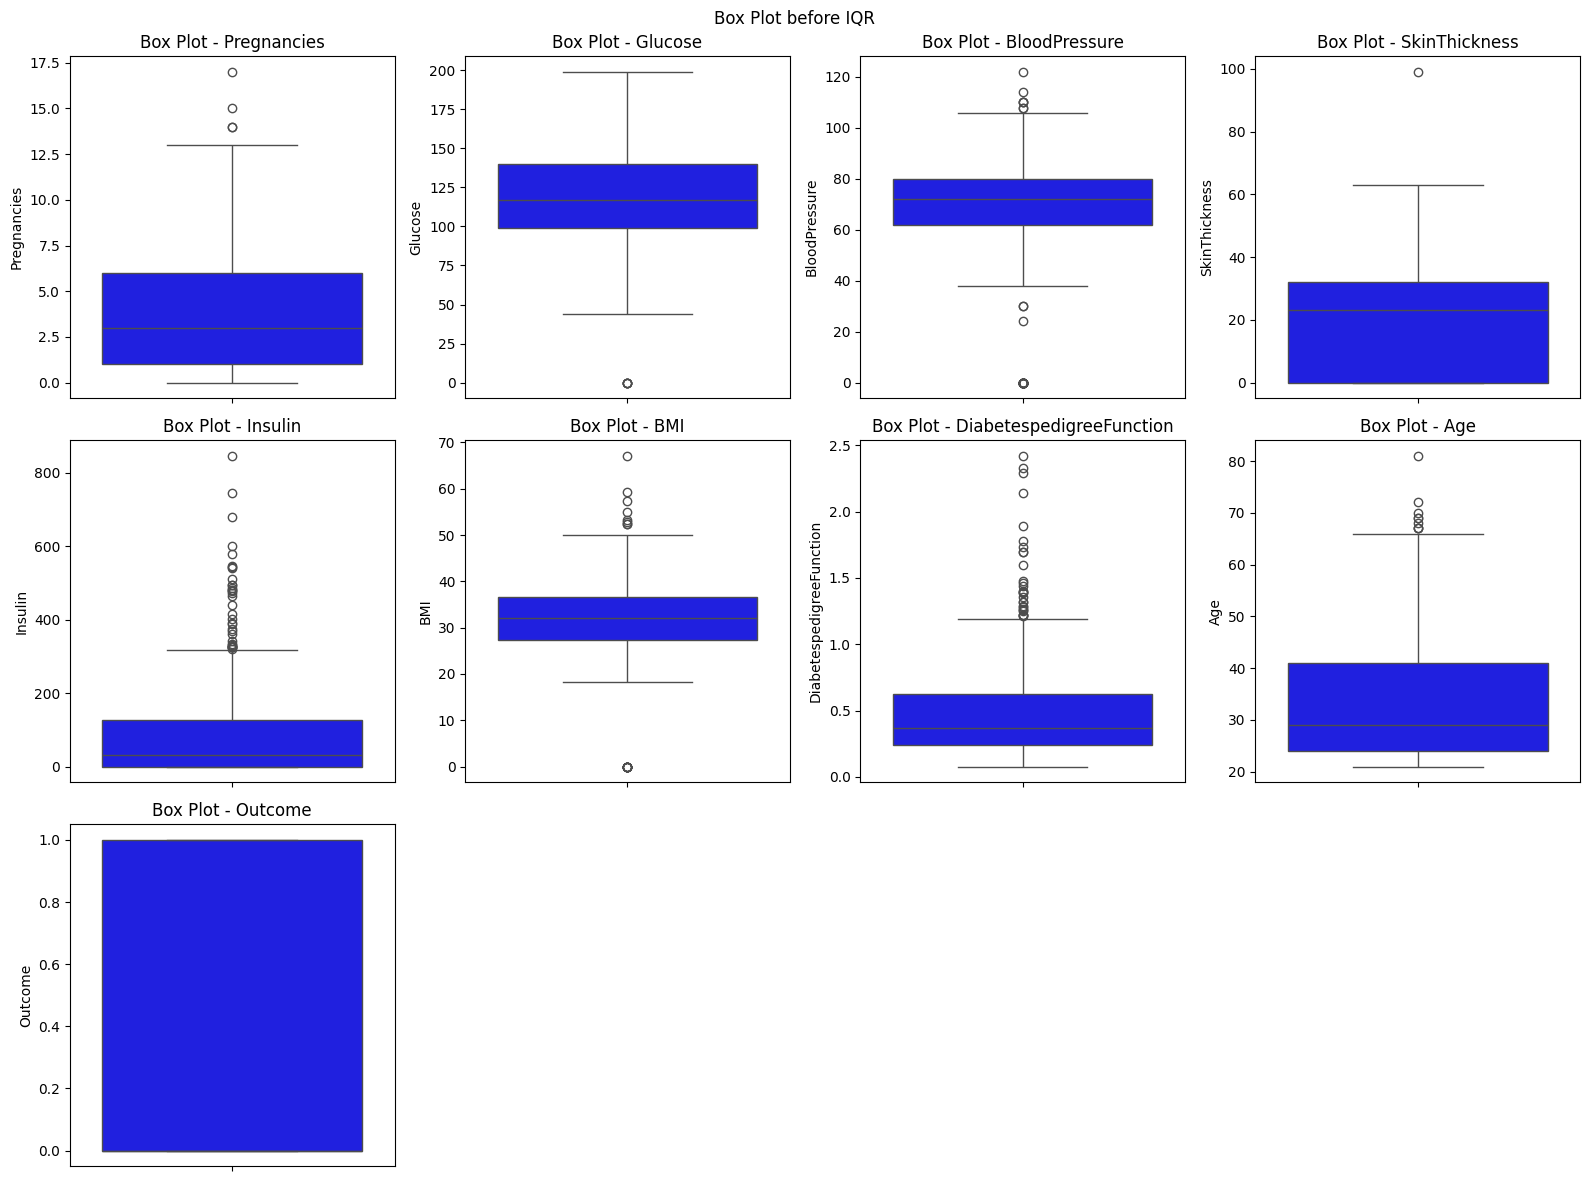

In [13]:
def box_plots_all_columns(df):
    num_cols = len(df.columns)
    num_rows = (num_cols + 3) // 4
    fig, axes = plt.subplots(num_rows, 4, figsize=(16, num_rows * 4))
    plt.suptitle("Box Plot before IQR")

    for i, column in enumerate(df.columns):
        row = i // 4
        col = i % 4
        sns.boxplot(df[column], ax=axes[row, col], color='blue')
        axes[row, col].set_title(f"Box Plot - {column}")

    for i in range(num_cols, num_rows * 4):
        fig.delaxes(axes.flatten()[i])

    plt.tight_layout()
    plt.show()

box_plots_all_columns(df)

As can be seen from the data visualization above, there are outliers in the dataset used. Therefore, the outliers need to be addressed.

The IQR tells us about the variation in a dataset; any value falling outside the range of -1.5 × IQR to 1.5 × IQR is treated as an outlier.

1. Q1 represents the first quartile / 25th percentile of the data.
2. Q2 represents the second quartile / median / 50th percentile of the data.
3. Q3 represents the third quartile / 75th percentile of the data.
4. (Q1 - 1.5IQR) represents the smallest value in the dataset, and (Q3 + 1.5IQR) represents the largest value in the dataset.

In [14]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR=Q3-Q1
df=df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)]

df.shape

(639, 9)

Displaying the results of data visualization after applying the IQR technique.

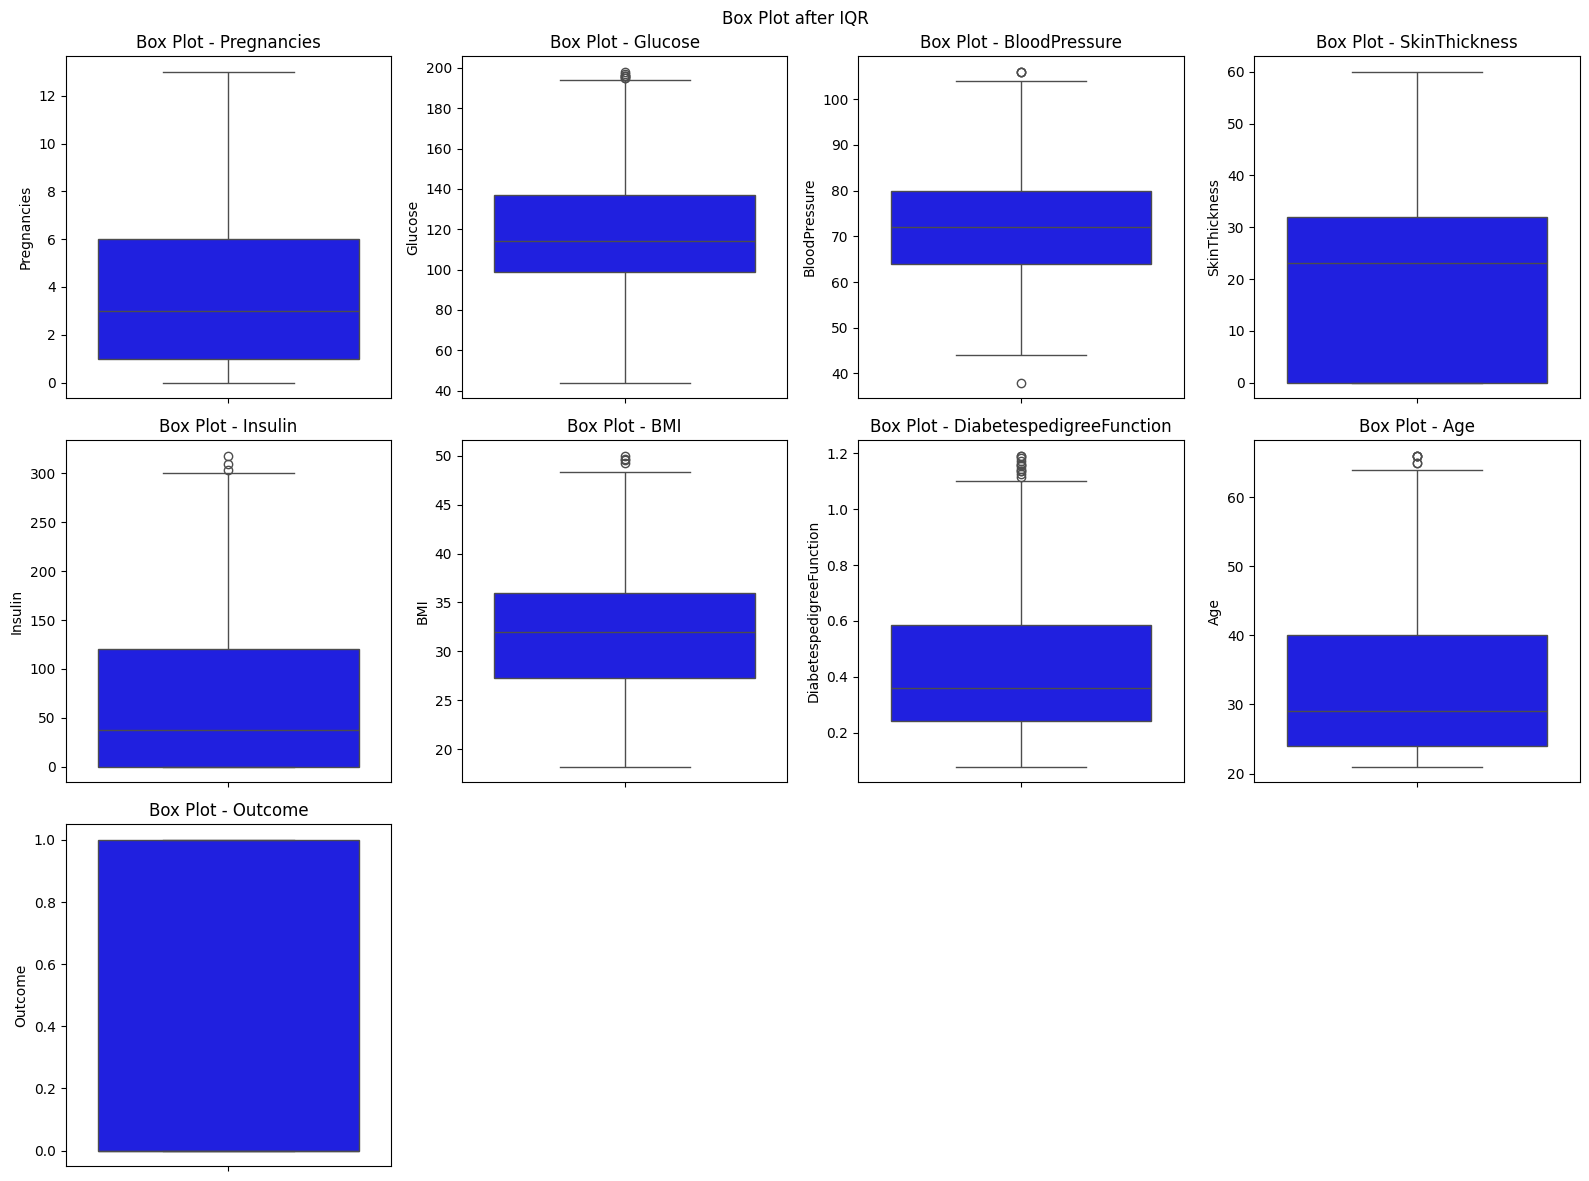

In [15]:
def box_plots_all_columns(df):
    num_cols = len(df.columns)
    num_rows = (num_cols + 3) // 4
    fig, axes = plt.subplots(num_rows, 4, figsize=(16, num_rows * 4))
    plt.suptitle("Box Plot after IQR")

    for i, column in enumerate(df.columns):
        row = i // 4
        col = i % 4
        sns.boxplot(df[column], ax=axes[row, col], color='blue')
        axes[row, col].set_title(f"Box Plot - {column}")

    for i in range(num_cols, num_rows * 4):
        fig.delaxes(axes.flatten()[i])

    plt.tight_layout()
    plt.show()

box_plots_all_columns(df)

# **Data splitting**
The next step is to split the dataset into training and test data. The training data will be used in the model training process, and the test data will be used to evaluate how well the trained model generalizes to new, unseen data.

In this case, the dataset will be split in an 80:20 ratio, with 80% allocated to training data and 20% to test data.

Based on the results of a comparison of the number of diabetes patients and non-diabetes patients, it is evident that the data set consists of only 34.9% diabetes patients and 65.1% non-diabetes patients. This indicates that the data is imbalanced. Therefore, it is necessary to address this data imbalance, as imbalanced data can lead to bias in the model and result in inaccurate predictions.

There are two methods for handling imbalanced data: oversampling and undersampling, depending on the specific case and the dataset at hand.

Oversampling: Used when dealing with a small dataset and aiming to sample more from the minority class. Oversampling using SMOTE can help improve model accuracy since it does not discard data; however, it may increase the risk of overfitting if not managed properly.

Undersampling: Used when you have a large dataset and want to reduce the number of samples from the majority class. Undersampling can help reduce training time and improve class balance, but it can reduce useful information if samples from the majority class are removed randomly.

In this case, we will apply the oversampling method because the dataset used falls into the small category, so using this method can make the dataset balanced.

In [16]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Split the data first
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Calculate the distribution before SMOTE
counter_before = Counter(y_train)

# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Calculate the distribution after SMOTE
counter_after = Counter(y_train_res)

print("After oversampling:", counter_after)

After oversampling: Counter({0: 351, 1: 351})


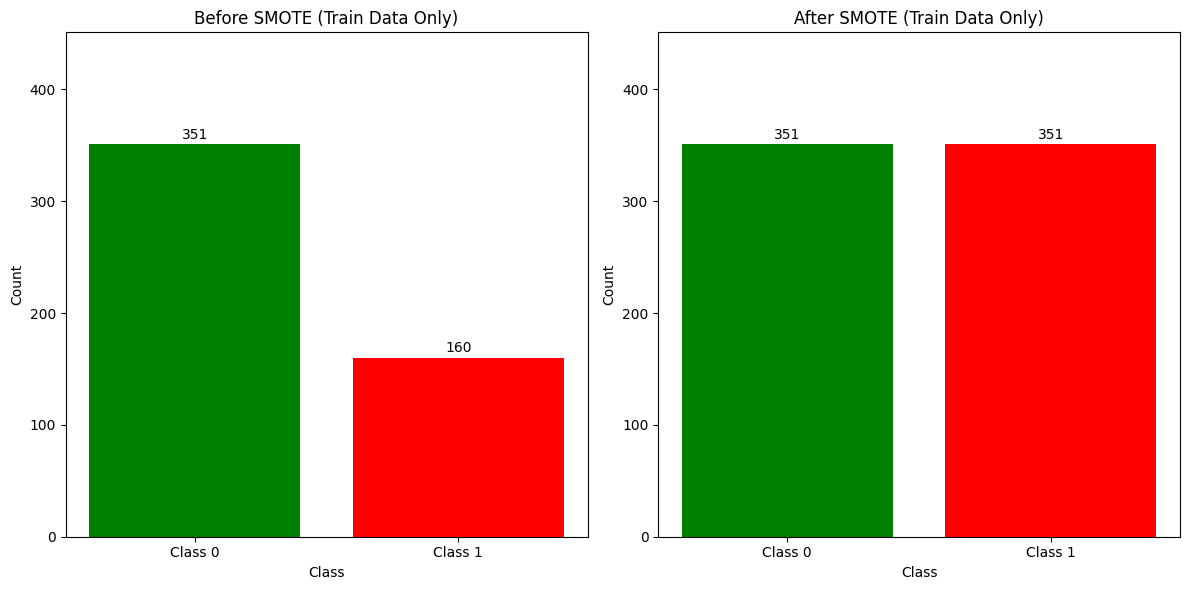

In [17]:
# Visualization
plt.figure(figsize=(12, 6))
class_labels = list(counter_before.keys())
colors = ['green', 'red']

# Before SMOTE
plt.subplot(1, 2, 1)
plt.bar(class_labels, [counter_before[label] for label in class_labels], color=colors)
plt.xticks(class_labels, labels=[f'Class {label}' for label in class_labels])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Before SMOTE (Train Data Only)')
plt.ylim(0, max(counter_after.values()) + 100)

for i, v in enumerate([counter_before[label] for label in class_labels]):
    plt.text(class_labels[i], v + 5, str(v), ha='center')

# After SMOTE
plt.subplot(1, 2, 2)
plt.bar(class_labels, [counter_after[label] for label in class_labels], color=colors)
plt.xticks(class_labels, labels=[f'Class {label}' for label in class_labels])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('After SMOTE (Train Data Only)')
plt.ylim(0, max(counter_after.values()) + 100)

for i, v in enumerate([counter_after[label] for label in class_labels]):
    plt.text(class_labels[i], v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

The imbalanced data has been successfully addressed, the data is now balanced and can be used for the model development phase.

# **Standardization**
Before developing a machine learning model, a standardization process is performed first. This step is used to process the numerical features in the data so that they have a mean of 0 and a standard deviation of 1. One of the goals of standardization is that many machine learning algorithms perform better or more consistently when numerical features are on the same scale. Through standardization, these features are treated uniformly, which can improve model performance.

In [18]:
# Initializing StandardScaler
scaler = StandardScaler()

# Fit and transform only the training data
X_train_scaled = scaler.fit_transform(X_train_res)

# Data transformation testing (without fitting)
X_test_scaled = scaler.transform(X_test)

# Check the results after standardization
print("Data setelah standarisasi (training set):")
print(X_train_scaled[:5])  # See the first few lines

Data setelah standarisasi (training set):
[[-0.6505748  -1.35417043 -0.61484662  0.19019796 -0.20250053 -0.06073523
   0.23500119 -1.10370806]
 [ 1.20343133 -0.15950897  1.19110454 -1.29478088 -0.79994264 -0.68091036
  -0.76367972 -1.10370806]
 [ 0.89443031 -0.35323785 -0.61484662 -1.29478088 -0.79994264  0.03718716
  -0.76787586  0.72516733]
 [-0.6505748   0.13108436  0.10753384  0.38389085  1.64957     0.10246875
   0.62943819 -0.82937675]
 [ 1.82143338 -1.83849264  2.9970557   0.19019796 -0.21444938  0.47783791
  -0.65458012  1.18238617]]


Decision Tree - Mean Accuracy from Cross-Validation: 0.7708 ± 0.0431
Accuracy on Test Set: 0.6875

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78        88
           1       0.50      0.47      0.49        40

    accuracy                           0.69       128
   macro avg       0.63      0.63      0.63       128
weighted avg       0.68      0.69      0.69       128



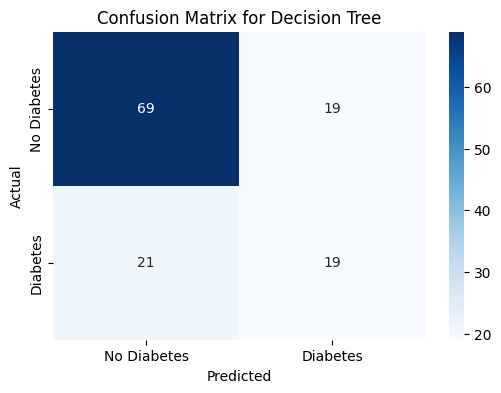

Naive Bayes - Mean Accuracy from Cross-Validation: 0.7379 ± 0.0400
Accuracy on Test Set: 0.6953

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.70      0.76        88
           1       0.51      0.68      0.58        40

    accuracy                           0.70       128
   macro avg       0.67      0.69      0.67       128
weighted avg       0.73      0.70      0.70       128



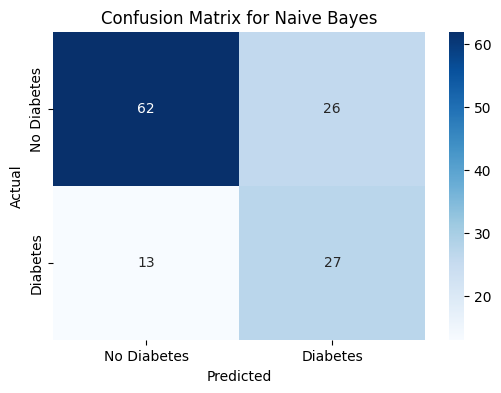

KNN - Mean Accuracy from Cross-Validation: 0.7665 ± 0.0458
Accuracy on Test Set: 0.7109

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.69      0.77        88
           1       0.53      0.75      0.62        40

    accuracy                           0.71       128
   macro avg       0.69      0.72      0.69       128
weighted avg       0.76      0.71      0.72       128



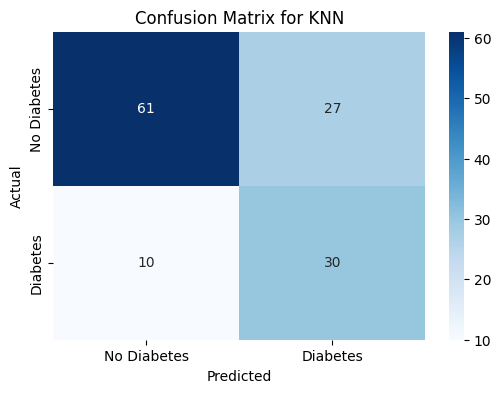

Logistic Regression - Mean Accuracy from Cross-Validation: 0.7406 ± 0.0424
Accuracy on Test Set: 0.7422

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80        88
           1       0.57      0.70      0.63        40

    accuracy                           0.74       128
   macro avg       0.71      0.73      0.72       128
weighted avg       0.76      0.74      0.75       128



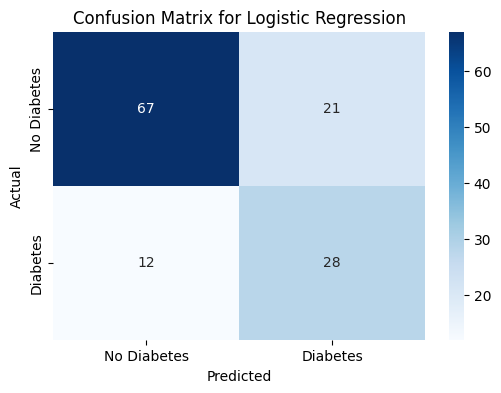

Random Forest - Mean Accuracy from Cross-Validation: 0.8448 ± 0.0332
Accuracy on Test Set: 0.7656

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        88
           1       0.60      0.72      0.66        40

    accuracy                           0.77       128
   macro avg       0.73      0.75      0.74       128
weighted avg       0.78      0.77      0.77       128



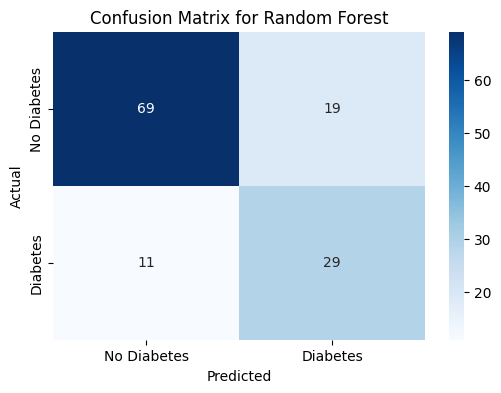

In [19]:
# List of algorithms to be tested
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train and evaluate all models on the standardized test set
for name, model in models.items():
    # Cross-validation on a standardized and resampled (SMOTE) training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train_res, cv=10, scoring='accuracy')
    mean_accuracy = np.mean(cv_scores)
    std_deviation = np.std(cv_scores)

    # Train the model on a standardized and resampled (SMOTE) training set
    model.fit(X_train_scaled, y_train_res)

    # Predictions on the standardized test set
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Show results
    print(f"{name} - Mean Accuracy from Cross-Validation: {mean_accuracy:.4f} ± {std_deviation:.4f}")
    print(f"Accuracy on Test Set: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("="*50)

    # Creating a Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualize the Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

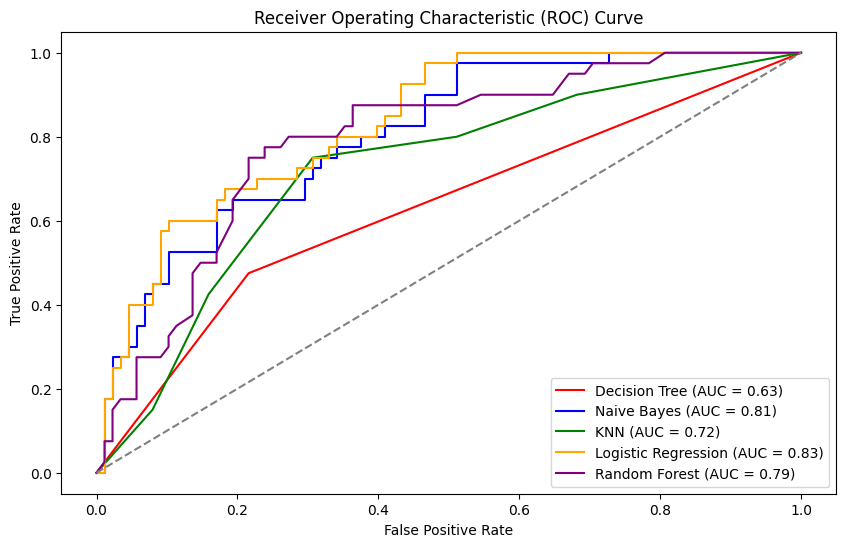

Model: Decision Tree
Accuracy: 0.69
Precision: 0.68
Recall: 0.69
F1-Score: 0.69
Model: Naive Bayes
Accuracy: 0.7
Precision: 0.73
Recall: 0.7
F1-Score: 0.7
Model: KNN
Accuracy: 0.71
Precision: 0.76
Recall: 0.71
F1-Score: 0.72
Model: Logistic Regression
Accuracy: 0.74
Precision: 0.76
Recall: 0.74
F1-Score: 0.75
Model: Random Forest
Accuracy: 0.77
Precision: 0.78
Recall: 0.77
F1-Score: 0.77


In [20]:
# List of algorithms to be tested
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Colors for each model
colors = {
    'Decision Tree': 'red',
    'Naive Bayes': 'blue',
    'KNN': 'green',
    'Logistic Regression': 'orange',
    'Random Forest': 'purple'
}

# Initialize a list to store the evaluation results
results = []

# Initializing the ROC curve plot
plt.figure(figsize=(10, 6))

for name, model in models.items():
    # Train the model on the training data
    model.fit(X_train_scaled, y_train_res)

    # Class prediction on the test set
    y_pred = model.predict(X_test_scaled)

    # Prediction probability (for the ROC curve)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    # Save the model evaluation results
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 2),
        "Precision": round(precision_score(y_test, y_pred, average='weighted'), 2),
        "Recall": round(recall_score(y_test, y_pred, average='weighted'), 2),
        "F1-Score": round(f1_score(y_test, y_pred, average='weighted'), 2)
    })

    # Plot the ROC curve if the probability is available
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[name], label=f'{name} (AUC = {roc_auc:.2f})')

# Add a diagonal reference line (random pattern)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Add labels and titles
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

# Print the model evaluation results
for result in results:
    print(f"Model: {result['Model']}")
    print(f"Accuracy: {result['Accuracy']}")
    print(f"Precision: {result['Precision']}")
    print(f"Recall: {result['Recall']}")
    print(f"F1-Score: {result['F1-Score']}")
    print("="*50)

In [21]:
# Convert the results to a DataFrame, sort by Accuracy, and display them
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-Score
4        Random Forest      0.77       0.78    0.77      0.77
3  Logistic Regression      0.74       0.76    0.74      0.75
2                  KNN      0.71       0.76    0.71      0.72
1          Naive Bayes      0.70       0.73    0.70      0.70
0        Decision Tree      0.69       0.68    0.69      0.69


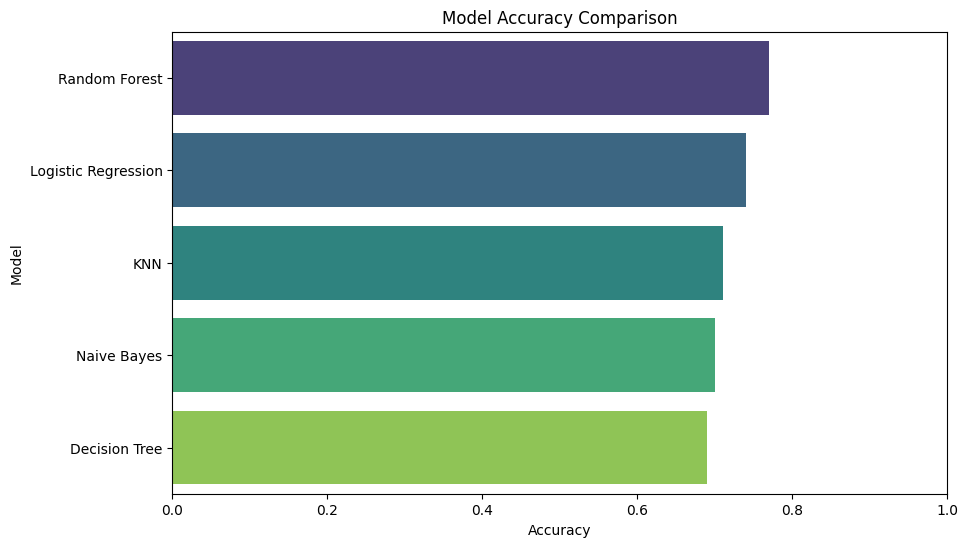

In [22]:
# Visualization of evaluation results
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()

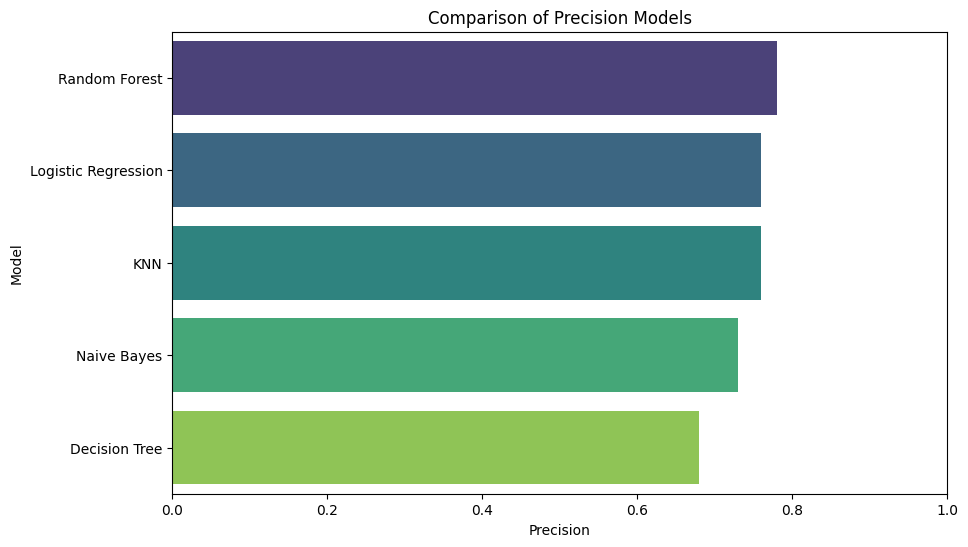

In [23]:
# Visualization of evaluation results
plt.figure(figsize=(10, 6))
sns.barplot(x="Precision", y="Model", data=results_df, palette="viridis")
plt.xlabel("Precision")
plt.ylabel("Model")
plt.title("Comparison of Precision Models")
plt.xlim(0, 1)
plt.show()

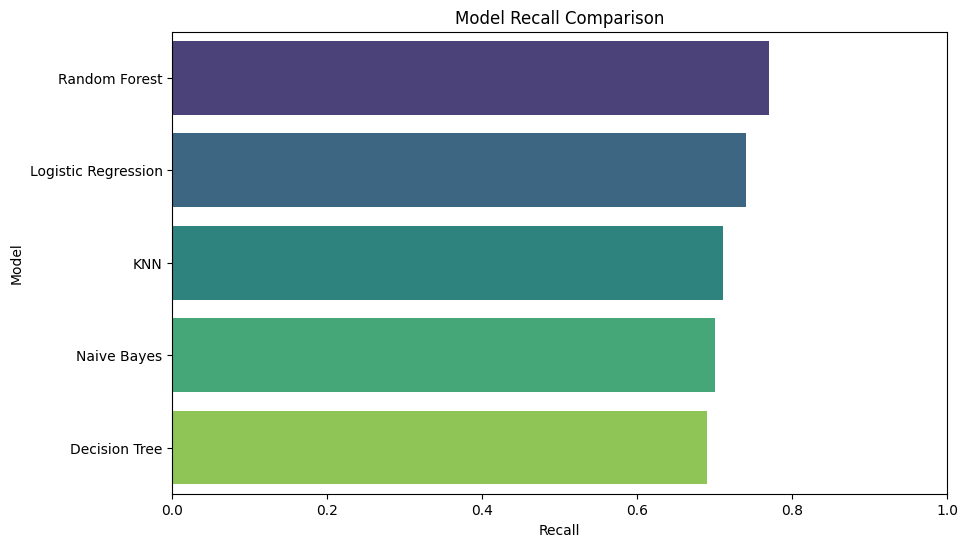

In [24]:
# Visualization of evaluation results
plt.figure(figsize=(10, 6))
sns.barplot(x="Recall", y="Model", data=results_df, palette="viridis")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.title("Model Recall Comparison")
plt.xlim(0, 1)
plt.show()

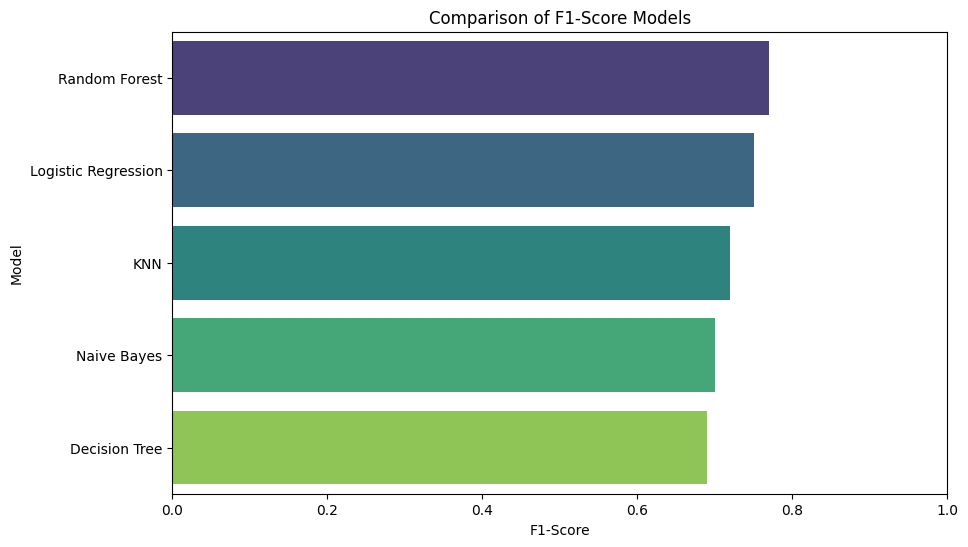

In [25]:
# Visualization of evaluation results
plt.figure(figsize=(10, 6))
sns.barplot(x="F1-Score", y="Model", data=results_df, palette="viridis")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.title("Comparison of F1-Score Models")
plt.xlim(0, 1)
plt.show()